In [12]:
import numpy as np 

class Perceptron(object):
   
    def __init__(self, input_size, lr=0.2, epochs=4):
        self.W = np.array([1.0,1.0])
        self.epochs = epochs
        self.lr = lr
    
    def activation_fn(self, x):
        return 1 if x >= 0 else 0
 
    def predict(self, x,theta):
        z = self.W.T.dot(x)-theta
        z=round(z,2)
        a = self.activation_fn(z)
        return a
    
    def fit(self, X, d,theta ,count):
        for _ in range(self.epochs):
            
            print("Epoch: ", count)
            count = count+1
            for i in range(d.shape[0]):
                x = X[i]
                print("input", x , "\t", "Weight:",self.W )
                y = self.predict(x,theta)
                e = d[i] - y
                self.W = self.W + self.lr * e * x
                
if __name__ == '__main__':
    X = np.array([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ])
    d = np.array([0, 0, 0, 1])
 
    perceptron = Perceptron(input_size=2)
    theta=1.5
    count =1
    perceptron.fit(X, d,theta, count)
    print(perceptron.W)


Epoch:  1
input [0 0] 	 Weight: [1. 1.]
input [0 1] 	 Weight: [1. 1.]
input [1 0] 	 Weight: [1. 1.]
input [1 1] 	 Weight: [1. 1.]
Epoch:  2
input [0 0] 	 Weight: [1. 1.]
input [0 1] 	 Weight: [1. 1.]
input [1 0] 	 Weight: [1. 1.]
input [1 1] 	 Weight: [1. 1.]
Epoch:  3
input [0 0] 	 Weight: [1. 1.]
input [0 1] 	 Weight: [1. 1.]
input [1 0] 	 Weight: [1. 1.]
input [1 1] 	 Weight: [1. 1.]
Epoch:  4
input [0 0] 	 Weight: [1. 1.]
input [0 1] 	 Weight: [1. 1.]
input [1 0] 	 Weight: [1. 1.]
input [1 1] 	 Weight: [1. 1.]
[1. 1.]


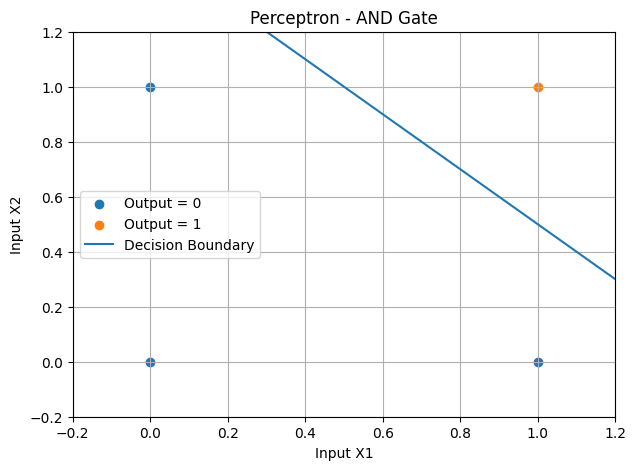

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))

# Plot class 0
plt.scatter(
    X[d == 0, 0],
    X[d == 0, 1],
    label="Output = 0"
)

# Plot class 1
plt.scatter(
    X[d == 1, 0],
    X[d == 1, 1],
    label="Output = 1"
)

# Get final weights
w1 = perceptron.W[0]
w2 = perceptron.W[1]

# Decision boundary:
# w1*x1 + w2*x2 - theta = 0
#
# Therefore:
# x2 = (theta - w1*x1) / w2

x1 = np.linspace(-0.2, 1.2, 100)

if w2 != 0:
    x2 = (theta - w1 * x1) / w2
    plt.plot(x1, x2, label="Decision Boundary")

# Labels
plt.xlabel("Input X1")
plt.ylabel("Input X2")
plt.title("Perceptron - AND Gate")

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)

plt.grid(True)
plt.legend()

plt.show()

In [7]:

import numpy as np


# -----------------------------
# Activation function
# -----------------------------

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)


# -----------------------------
# Check error
# -----------------------------

def checkError(predicted_output, expected_output):
    for i in range(len(expected_output)):
        if abs(expected_output[i][0] - predicted_output[i][0]) > 0.001:
            return True

    return False


# -----------------------------
# Input data - XOR
# -----------------------------

inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

expected_output = np.array([
    [0],
    [1],
    [1],
    [0]
])


# -----------------------------
# Network structure
# -----------------------------

inputLayerNeurons = 2
hiddenLayerNeurons = 2
outputLayerNeurons = 1

lr = 0.5
epoch = 0
max_epochs = 100000


# -----------------------------
# Random initial weights
# -----------------------------

np.random.seed(42)

hidden_weights = np.random.uniform(
    -1, 1,
    (inputLayerNeurons, hiddenLayerNeurons)
)

output_weights = np.random.uniform(
    -1, 1,
    (hiddenLayerNeurons, outputLayerNeurons)
)

hidden_bias = np.random.uniform(
    -1, 1,
    (1, hiddenLayerNeurons)
)

output_bias = np.random.uniform(
    -1, 1,
    (1, outputLayerNeurons)
)


# -----------------------------
# Print initial values
# -----------------------------

print("Initial hidden weights:")
print(hidden_weights)

print("\nInitial hidden bias:")
print(hidden_bias)

print("\nInitial output weights:")
print(output_weights)

print("\nInitial output bias:")
print(output_bias)


# -----------------------------
# Initial prediction
# -----------------------------

predicted_output = np.zeros((4, 1))


# =====================================================
# TRAINING
# =====================================================

while checkError(predicted_output, expected_output) and epoch < max_epochs:

    epoch += 1

    # -------------------------
    # Forward propagation
    # -------------------------

    # Input -> Hidden layer
    hidden_layer_activation = np.dot(inputs, hidden_weights)
    hidden_layer_activation += hidden_bias

    hidden_layer_output = sigmoid(hidden_layer_activation)


    # Hidden -> Output layer
    output_layer_activation = np.dot(
        hidden_layer_output,
        output_weights
    )

    output_layer_activation += output_bias

    predicted_output = sigmoid(output_layer_activation)


    # -------------------------
    # Backpropagation
    # -------------------------

    error = expected_output - predicted_output

    d_predicted_output = (
        error *
        sigmoid_derivative(predicted_output)
    )


    # Hidden layer error
    error_hidden_layer = np.dot(
        d_predicted_output,
        output_weights.T
    )

    d_hidden_layer = (
        error_hidden_layer *
        sigmoid_derivative(hidden_layer_output)
    )


    # -------------------------
    # Update output weights
    # -------------------------

    output_weights += (
        np.dot(hidden_layer_output.T, d_predicted_output)
        * lr
    )

    output_bias += (
        np.sum(d_predicted_output, axis=0, keepdims=True)
        * lr
    )


    # -------------------------
    # Update hidden weights
    # -------------------------

    hidden_weights += (
        np.dot(inputs.T, d_hidden_layer)
        * lr
    )

    hidden_bias += (
        np.sum(d_hidden_layer, axis=0, keepdims=True)
        * lr
    )


# =====================================================
# RESULTS
# =====================================================

print("\n--------------------------------")
print("Training completed")
print("--------------------------------")

print("\nNumber of epochs:")
print(epoch)

print("\nFinal hidden weights:")
print(hidden_weights)

print("\nFinal hidden bias:")
print(hidden_bias)

print("\nFinal output weights:")
print(output_weights)

print("\nFinal output bias:")
print(output_bias)

print("\nOutput from neural network:")

for i in range(len(inputs)):
    print(
        inputs[i],
        "=>",
        predicted_output[i][0]
    )


Initial hidden weights:
[[-0.25091976  0.90142861]
 [ 0.46398788  0.19731697]]

Initial hidden bias:
[[-0.88383278  0.73235229]]

Initial output weights:
[[-0.68796272]
 [-0.68801096]]

Initial output bias:
[[0.20223002]]

--------------------------------
Training completed
--------------------------------

Number of epochs:
100000

Final hidden weights:
[[-7.23723552  7.87116224]
 [ 7.48452717 -7.72312243]]

Final hidden bias:
[[3.63489217 3.91172277]]

Final output weights:
[[-10.72751456]
 [-10.67780748]]

Final output bias:
[[15.87674397]]

Output from neural network:
[0 0] => 0.006410702912786786
[0 1] => 0.9927417388109947
[1 0] => 0.9927129537812689
[1 1] => 0.0058765815561337914


X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)
Test Accuracy: 0.633


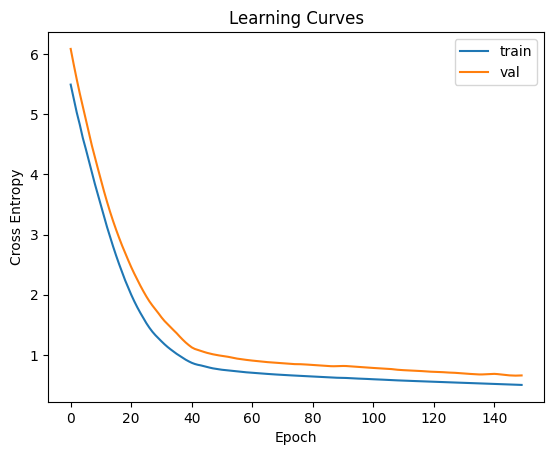

In [9]:
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot

#  Read the dataset ‘Iris.csv’ 
df = read_csv('Iris.csv')

#  Split the Iris features into input and output columns
X = df.values[:, :-1]
y = df.values[:, -1]

# Check all data are floating point values
X = X.astype('float32')

# Encode the strings of labels to integer values
y = LabelEncoder().fit_transform(y)

# Split the data matrix into train and test dataset and Print the shape of train dataset and test dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = True, random_state = 123)
print("X_train shape: {}".format(X_train.shape))
print("X_test shape: {}".format(X_test.shape))
print("y_train shape: {}".format(y_train.shape))
print("y_test shape: {}".format(y_test.shape))
# split randomly the data matrix into training dataset and validation dataset 
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

# Determine the number of input features
n_features = X_train.shape[1]

# Define the model
model = Sequential()
model.add(Dense(10, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
model.add(Dense(8, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(3, activation='softmax'))

# Compile the model
sgd = SGD(learning_rate=0.001, momentum=0.8)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
history = model.fit(X_train, y_train, epochs=150, batch_size=32, verbose=0, validation_split=0.3)

# Evaluate the model and print the accuracy
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print('Test Accuracy: %.3f' % acc)

# Visualize by plotting the learning curves
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='val')
pyplot.legend()
pyplot.show()


X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)
Test Accuracy: 0.200


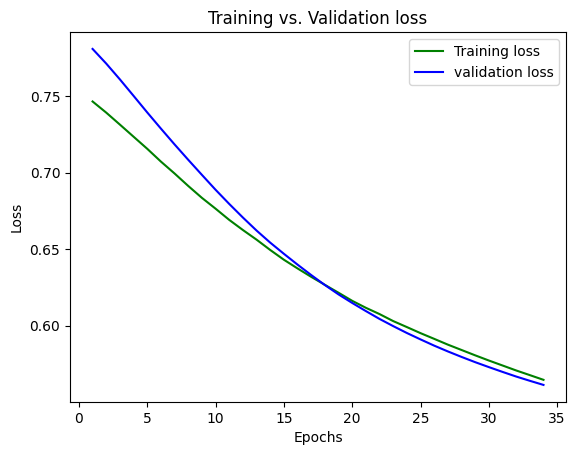

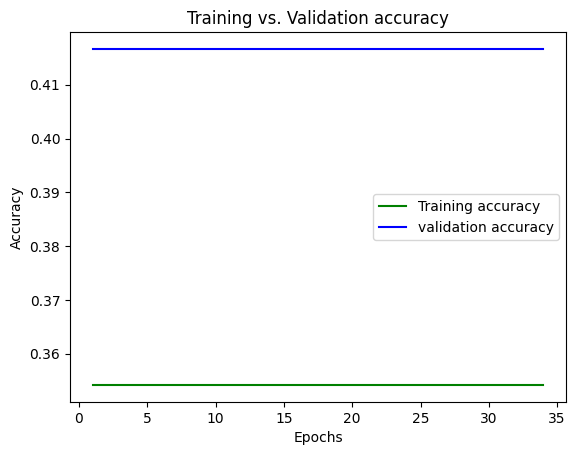

In [11]:
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from matplotlib import pyplot as plt
#  Read the dataset ‘Iris.csv’ 
df = read_csv('Iris.csv')
#  Split the Iris features into input and output columns
X = df.values[:, :-1]
y = df.values[:, -1]

# Check all data are floating point values
X = X.astype('float32')
# Encode the strings of labels to integer values
y = LabelEncoder().fit_transform(y)
# Split the data matrix into train and test dataset and Print the shape of train dataset and test dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = True, random_state = 123)
print("X_train shape: {}".format(X_train.shape))
print("X_test shape: {}".format(X_test.shape))
print("y_train shape: {}".format(y_train.shape))
print("y_test shape: {}".format(y_test.shape))
# split randomly the data matrix into training dataset and validation dataset 
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

# Determine the number of input features
n_features = X_train.shape[1]

# Define model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(n_features,)),
    keras.layers.Dense(4, activation=tf.nn.relu),
    keras.layers.Dense(4, activation=tf.nn.relu),
    keras.layers.Dense(1, activation=tf.nn.sigmoid),
])
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])
# Fit the model
history = model.fit(X_train, y_train, epochs=34, batch_size=32, verbose=0, validation_data=(X_val, y_val))

# Evaluate the model and print the accuracy
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print('Test Accuracy: %.3f' % acc)

# Visualize 'Training vs. Validation loss'
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epochs = range(1,35)
plt.plot(epochs, loss_train, 'g', label='Training loss')
plt.plot(epochs, loss_val, 'b', label='validation loss')
plt.title('Training vs. Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Visualize 'Training  Accuracy vs. Validation accuracy'
loss_train = history.history['accuracy']
loss_val = history.history['val_accuracy']
epochs = range(1,35)
plt.plot(epochs, loss_train, 'g', label='Training accuracy')
plt.plot(epochs, loss_val, 'b', label='validation accuracy')
plt.title('Training vs. Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)
Test Accuracy: 0.200


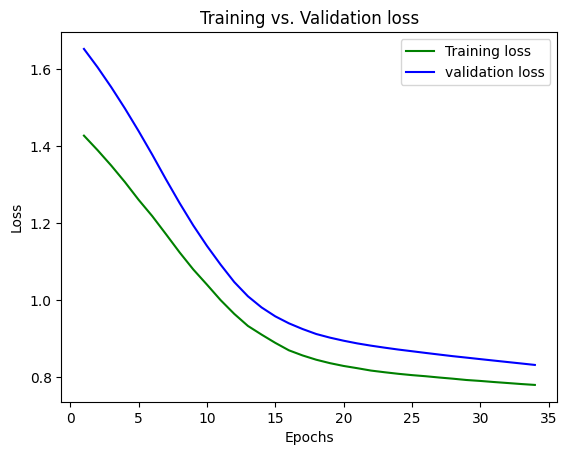

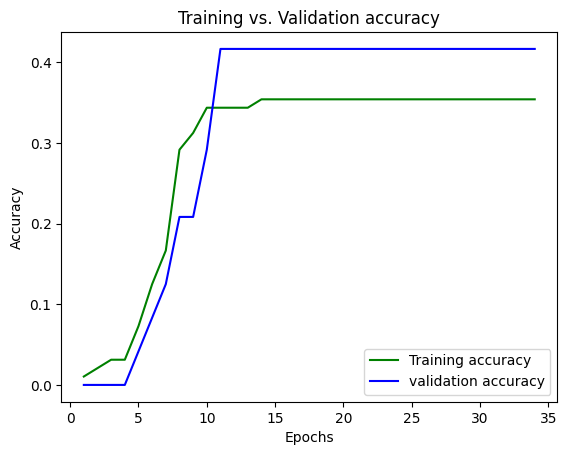

In [14]:
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from matplotlib import pyplot as plt
#  Read the dataset ‘Iris.csv’ 
df = read_csv('Iris.csv')
#  Split the Iris features into input and output columns
X = df.values[:, :-1]
y = df.values[:, -1]

# Check all data are floating point values
X = X.astype('float32')
# Encode the strings of labels to integer values
y = LabelEncoder().fit_transform(y)
# Split the data matrix into train and test dataset and Print the shape of train dataset and test dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = True, random_state = 123)
print("X_train shape: {}".format(X_train.shape))
print("X_test shape: {}".format(X_test.shape))
print("y_train shape: {}".format(y_train.shape))
print("y_test shape: {}".format(y_test.shape))
# split randomly the data matrix into training dataset and validation dataset 
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

# Determine the number of input features
n_features = X_train.shape[1]

# Define model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(n_features,)),
    keras.layers.Dense(4, activation=tf.nn.relu),
    keras.layers.Dense(4, activation=tf.nn.relu),
    keras.layers.Dense(1, activation=tf.nn.sigmoid),
])
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])
# Fit the model
history = model.fit(X_train, y_train, epochs=34, batch_size=32, verbose=0, validation_data=(X_val, y_val))

# Evaluate the model and print the accuracy
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print('Test Accuracy: %.3f' % acc)

# Visualize 'Training vs. Validation loss'
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epochs = range(1,35)
plt.plot(epochs, loss_train, 'g', label='Training loss')
plt.plot(epochs, loss_val, 'b', label='validation loss')
plt.title('Training vs. Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Visualize 'Training  Accuracy vs. Validation accuracy'
loss_train = history.history['accuracy']
loss_val = history.history['val_accuracy']
epochs = range(1,35)
plt.plot(epochs, loss_train, 'g', label='Training accuracy')
plt.plot(epochs, loss_val, 'b', label='validation accuracy')
plt.title('Training vs. Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
